In [91]:
import cartopy.crs as ccrs
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import xarray as xr
import xesmf as xe

from obs_io import add_weights, march_to_feb_years, seasonal_means, to_trend
from utils.plotting import central_lon, plot_colormesh, plot_coasts_grid, plot_colorbar, colors, edge_band

In [33]:
ta = xr.open_dataset("pp/regime_masks.nc").tropical_ascent
mask_union = ta.any(dim="season")
lon_vals = mask_union.lon.values
lat_vals = mask_union.lat.values

ceres = xr.open_mfdataset(["pp/ceres_trends.nc"]).sel(season="ANN")
lwclr_trend = ceres.where(mask_union).lw_clr

In [48]:
drivers_trends = xr.open_dataset('pp/era5_drivers_trends.nc').sel(season="ANN")
tcw_trend = drivers_trends.where(mask_union).tcw
crh_trend = drivers_trends.where(mask_union).column_rh * 100

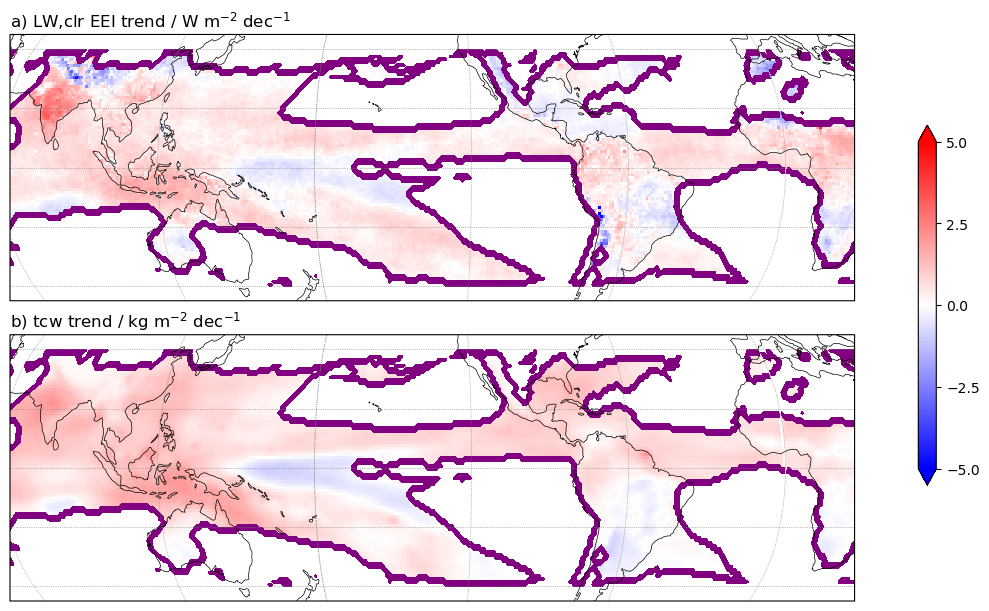

In [78]:
proj = ccrs.Robinson(central_longitude=central_lon)
fig,axes = plt.subplots(2, 1, figsize=(9,6), subplot_kw={"projection":proj}, constrained_layout=True)

ax = axes[0]
p = plot_colormesh(ax, lwclr_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("a) LW,clr EEI trend / W m$^{-2}$ dec$^{-1}$", loc="left")

ax = axes[1]
p = plot_colormesh(ax, tcw_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("b) tcw trend / kg m$^{-2}$ dec$^{-1}$", loc="left")

for ax in axes:
    ax.contourf(
        lon_vals, lat_vals, edge_band(mask_union).values,
        levels=[0.5, 1],
        colors=[colors['tropical_ascent']],
        alpha=1,
        transform=ccrs.PlateCarree(),
    )

plot_colorbar(fig, p, "", [1.04, 0.2, 0.02, 0.6], ori="vertical")

plt.show()

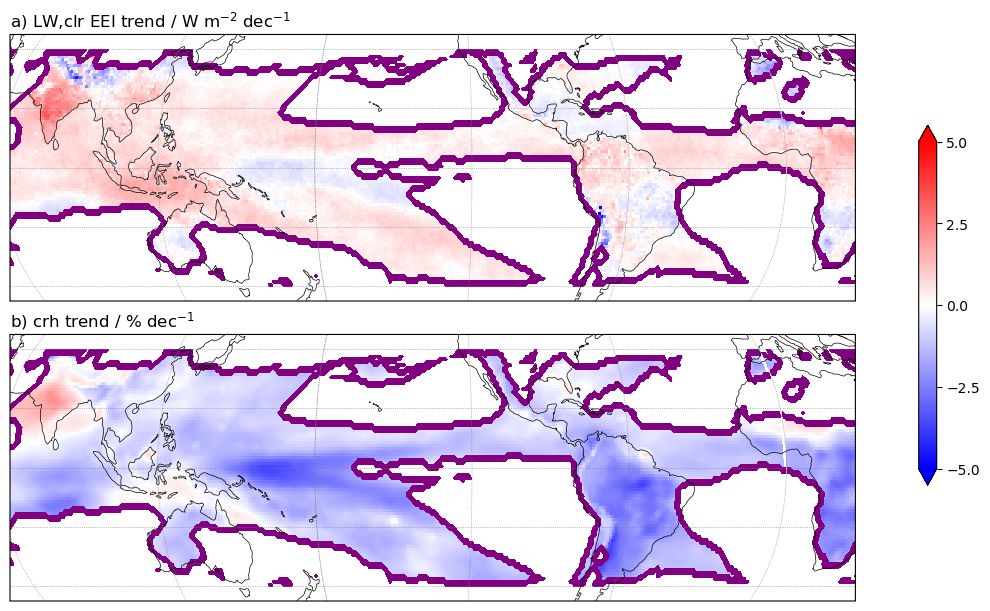

In [77]:
proj = ccrs.Robinson(central_longitude=central_lon)
fig,axes = plt.subplots(2, 1, figsize=(9,6), subplot_kw={"projection":proj}, constrained_layout=True)

ax = axes[0]
p = plot_colormesh(ax, lwclr_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("a) LW,clr EEI trend / W m$^{-2}$ dec$^{-1}$", loc="left")

ax = axes[1]
p = plot_colormesh(ax, crh_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("b) crh trend / % dec$^{-1}$", loc="left")

for ax in axes:
    ax.contourf(
        lon_vals, lat_vals, edge_band(mask_union).values,
        levels=[0.5, 1],
        colors=[colors['tropical_ascent']],
        alpha=1,
        transform=ccrs.PlateCarree(),
    )

plot_colorbar(fig, p, "", [1.04, 0.2, 0.02, 0.6], ori="vertical")

plt.show()

In [93]:
drivers = xr.open_mfdataset(["raw_data/drivers_levels.nc", "raw_data/drivers_levels_2026.nc", "raw_data/column_rh.nc"])
drivers = drivers.rename({'valid_time':"time", "latitude":"lat", "longitude":"lon"}).drop_vars(["number","expver"])

ceres = xr.open_dataset("pp/ceres_trends.nc")
ceres = ceres.sortby(["lat","lon"])
regridder = xe.Regridder(drivers, ceres, method="bilinear")
drivers = regridder(drivers)

drivers = drivers.sel(time=slice("2000-03-01", "2026-03-01"))
Ts = drivers.t2m
crh = drivers.column_rh
OLR_table = xr.open_dataset("raw_data/OLR_table.nc")

Ts_mean = Ts.mean("time")
ds = OLR_table.interp(rh=crh, ts=Ts_mean).drop_vars(["rh","ts"])
ds = add_weights(ds)
ds = march_to_feb_years(ds)
ds = seasonal_means(ds)
crh_lwclr_trend = to_trend(ds).sel(season="ANN").where(mask_union).olr

crh_lwclr_trend

<xarray.DataArray 'olr' (lat: 180, lon: 360)> Size: 518kB
dask.array<where, shape=(180, 360), dtype=float64, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    season   <U3 12B 'ANN'
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

In [ ]:
proj = ccrs.Robinson(central_longitude=central_lon)
fig,axes = plt.subplots(2, 1, figsize=(9,6), subplot_kw={"projection":proj}, constrained_layout=True)

ax = axes[0]
p = plot_colormesh(ax, lwclr_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("a) LW,clr EEI trend / W m$^{-2}$ dec$^{-1}$", loc="left")

ax = axes[1]
p = plot_colormesh(ax, crh_lwclr_trend)
plot_coasts_grid(ax)
ax.set_extent([-180, 180, -45, 45],crs=ccrs.PlateCarree())
ax.set_title("b) LW,clr EEI from CRH(t) trend / W m$^{-2}$ dec$^{-1}$", loc="left")

for ax in axes:
    ax.contourf(
        lon_vals, lat_vals, edge_band(mask_union).values,
        levels=[0.5, 1],
        colors=[colors['tropical_ascent']],
        alpha=1,
        transform=ccrs.PlateCarree(),
    )

plot_colorbar(fig, p, "", [1.04, 0.2, 0.02, 0.6], ori="vertical")

plt.show()